In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
df=pd.read_csv('/content/Churn_Modelling (1).csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [11]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [13]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [14]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [18]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [20]:
df.head()
df.shape

(10000, 12)

In [24]:
X=df.drop(columns=['Exited'])
Y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=1)

In [27]:
print(X_train.shape,X_test.shape)

(8000, 11) (2000, 11)


In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [30]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout,BatchNormalization

In [58]:
model = Sequential()
model.add(Dense(256, activation='relu', input_dim=11))
model.add(BatchNormalization())  # Batch Normalization after the first layer
model.add(Dropout(0.2))       # Dropout with a rate of 0.2

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(8, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,993 (191.38 KB)

 Trainable params: 47,985 (187.44 KB)

 Non-trainable params: 1,008 (3.94 KB)

In [61]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [68]:
history=model.fit(X_train_scaled,Y_train,epochs=100,verbose=1,validation_data=(X_test_scaled,Y_test))

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8773 - loss: 0.2966 - val_accuracy: 0.8610 - val_loss: 0.3691
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8856 - loss: 0.2854 - val_accuracy: 0.8545 - val_loss: 0.3764
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8791 - loss: 0.2903 - val_accuracy: 0.8645 - val_loss: 0.3592
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8766 - loss: 0.2902 - val_accuracy: 0.8505 - val_loss: 0.3789
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8812 - loss: 0.2881 - val_accuracy: 0.8610 - val_loss: 0.3683
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8904 - loss: 0.2784 - val_accuracy: 0.8640 - val_loss: 0.3679
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8715 - loss: 0.3028 - val_accuracy: 0.8590 - val_loss: 0.3671
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8929 - loss: 0.2646 - val_accu

In [63]:
model.layers[0].get_weights()

[array([[ 0.21598406, -0.11976797,  0.06595459, ..., -0.13911542,
          0.15125653,  0.03829238],
        [-0.12695609, -0.38322374, -0.42778945, ..., -0.04578942,
         -0.1820204 , -0.01763903],
        [-0.10090279,  0.10228968, -0.0987156 , ...,  0.03837251,
          0.07185367,  0.13871308],
        ...,
        [ 0.13816246,  0.13000372,  0.04046835, ..., -0.2022145 ,
         -0.04805665,  0.00663475],
        [ 0.00139575,  0.17137344, -0.13424885, ...,  0.08595791,
         -0.21224554,  0.13059604],
        [ 0.20503631, -0.12077371, -0.19988906, ...,  0.25952676,
          0.12174864, -0.00428565]], dtype=float32),
 array([-0.18054853,  0.07096539,  0.08809155, -0.16942278, -0.05822425,
         0.3706568 ,  0.04582674, -0.52044755, -0.36950457,  0.11633293,
        -0.46104413, -0.05647987, -0.4545233 , -0.04464655, -0.23415692,
        -0.3914723 , -0.18265136, -0.5134225 ,  0.01546384, -0.27044588,
        -0.15545045, -0.03018459, -0.3800783 , -0.17369719, -0.158

In [64]:
model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


array([[0.00903991],
       [0.2317974 ],
       [0.00803234],
       ...,
       [0.00081609],
       [0.02096258],
       [0.62749   ]], dtype=float32)

In [65]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [66]:
y_pred=np.where(y_log>0.5,1,0)

In [67]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.8605

In [69]:
import matplotlib.pyplot as plt
history.history

{'accuracy': [0.8777499794960022,
  0.875,
  0.8778749704360962,
  0.8768749833106995,
  0.8784999847412109,
  0.8823750019073486,
  0.8766250014305115,
  0.8826249837875366,
  0.878250002861023,
  0.8791249990463257,
  0.878125011920929,
  0.8817499876022339,
  0.8771250247955322,
  0.8822500109672546,
  0.8840000033378601,
  0.8786249756813049,
  0.8759999871253967,
  0.8793749809265137,
  0.8866249918937683,
  0.8774999976158142,
  0.8806250095367432,
  0.8805000185966492,
  0.8787500262260437,
  0.8832499980926514,
  0.8803750276565552,
  0.8842499852180481,
  0.8822500109672546,
  0.8824999928474426,
  0.8843749761581421,
  0.8893749713897705,
  0.8759999871253967,
  0.8834999799728394,
  0.8777499794960022,
  0.8870000243186951,
  0.8856250047683716,
  0.8815000057220459,
  0.8840000033378601,
  0.8826249837875366,
  0.8812500238418579,
  0.8857499957084656,
  0.8851249814033508,
  0.8832499980926514,
  0.8833749890327454,
  0.8813750147819519,
  0.8899999856948853,
  0.884874999

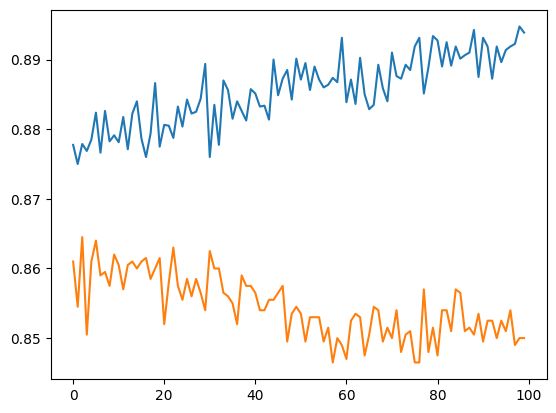

In [74]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

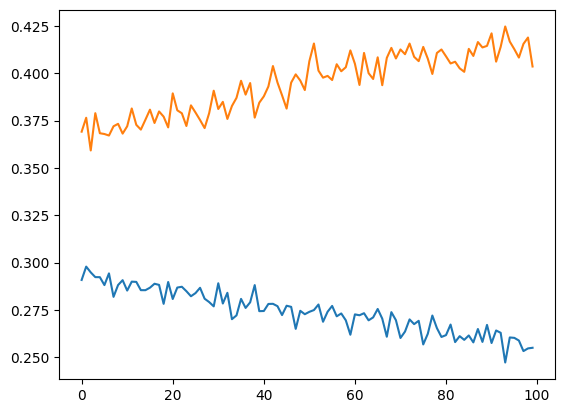

In [75]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [79]:
import numpy as np

num_samples = 10
num_features = 11
new_data = np.random.rand(num_samples, num_features)
new_data_scaled = scaler.transform(new_data)
predictions = model.predict(new_data_scaled)
predicted_labels = np.where(predictions >= 0.5, 1, 0)
print(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]
